# Task 3 - Neural Networks

> ### _Dans ce notebook, nous allons implémenter un réseau de neurones artificiels avec TensorFlow/Keras, l'un des modèles les plus puissants en machine learning, inspirés du fonctionnement du cerveau humain._



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Configuration de style personnalisé
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

##  2. Chargement et exploration des données



In [2]:
breast_cancer = load_breast_cancer()

# Création d'un DataFrame pandas
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 📈 Exploration des données

In [3]:
print("Shape of dataset:", df.shape)
print("\nInfo of dataset:")
df.info()

Shape of dataset: (569, 31)

Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-n

###  Statistiques descriptives

In [4]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Vérification de la distribution des classes (variable cible)

In [5]:
target_column = df.columns[-1]
print(f"Variable cible: {target_column}")
print("\nDistribution des classes:")
print(df[target_column].value_counts())

Variable cible: target

Distribution des classes:
target
1    357
0    212
Name: count, dtype: int64


### Visualisation stylée de la distribution des classes

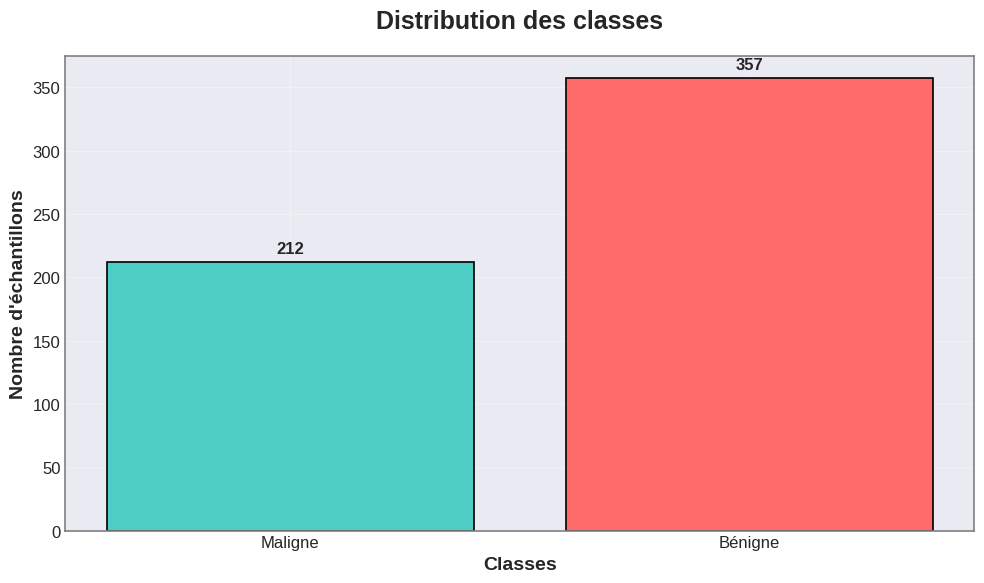

In [6]:
# Palette de couleurs personnalisée
colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(10, 6))
class_counts = df[target_column].value_counts()

bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=1.2)

# Ajout des valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.title('Distribution des classes', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Classes', fontsize=14, fontweight='bold')
plt.ylabel('Nombre d\'échantillons', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Maligne', 'Bénigne'], fontsize=12)
plt.grid(True, alpha=0.3)

# Ajout d'une bordure autour du graphique
for spine in plt.gca().spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

#  3. Prétraitement des données

In [7]:
X = df.iloc[:, :-1]  # Toutes les colonnes sauf la dernière
y = df.iloc[:, -1]   # Dernière colonne (variable cible)

print(f"Dimensions des caractéristiques: {X.shape}")
print(f"Dimensions de la variable cible: {y.shape}")

Dimensions des caractéristiques: (569, 30)
Dimensions de la variable cible: (569,)


###  Normalisation des données

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame pour faciliter la manipulation
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Données après normalisation:")
X_scaled.head()

Données après normalisation:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


4. Division des données

In [9]:
# Division des données en ensembles d'entraînement et test
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Division de l'ensemble temporaire en ensembles d'entraînement et de validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de validation: {X_val.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

Taille de l'ensemble d'entraînement: (364, 30)
Taille de l'ensemble de validation: (91, 30)
Taille de l'ensemble de test: (114, 30)




###  Visualisation de la répartition des données

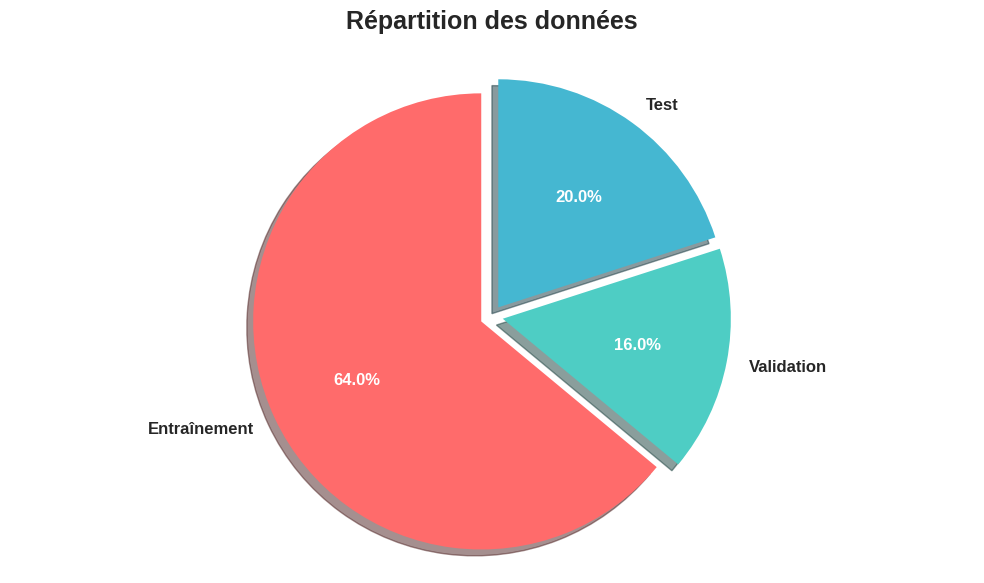

In [10]:
# Création d'une visualisation stylée de la répartition des données
fig, ax = plt.subplots(figsize=(10, 6))

# Données pour le diagramme circulaire
labels = ['Entraînement', 'Validation', 'Test']
sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0.05, 0.05)  # Espacement entre les parts

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                  autopct='%1.1f%%', shadow=True, startangle=90,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Style du texte
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.axis('equal')  # Assure que le camembert est dessiné comme un cercle
plt.title('Répartition des données', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Construction du modèle de réseau de neurones

In [11]:
model = keras.Sequential([
    # Couche d'entrée
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),  # Dropout pour la régularisation

    # Première couche cachée
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    # Deuxième couche cachée
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    # Couche de sortie
    layers.Dense(1, activation='sigmoid')  # Sigmoid pour classification binaire
])

# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Affichage de la structure du modèle

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

### Visualisation de l'architecture du réseau de neurones

In [13]:
# Visualisation stylée de l'architecture
try:
    from tensorflow.keras.utils import plot_model
    plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)
    from IPython.display import Image
    Image('model.png')
except ImportError:
    print("Installation requise: pip install pydot")
    print("Et Graphviz: https://graphviz.org/download/")

 6. Entraînement du modèle

In [14]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.001
)

###  Entraînement du modèle

In [15]:
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4109 - loss: 0.8312 - val_accuracy: 0.8132 - val_loss: 0.6027 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7023 - loss: 0.6080 - val_accuracy: 0.8901 - val_loss: 0.4606 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8336 - loss: 0.4759 - val_accuracy: 0.9231 - val_loss: 0.3467 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8664 - loss: 0.3966 - val_accuracy: 0.9560 - val_loss: 0.2577 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9186 - loss: 0.2711 - val_accuracy: 0.9560 - val_loss: 0.1959 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9392 - loss: 0.2059 - val_accuracy: 0.9560 - val_loss: 0.1613 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9270 - loss: 0.2006 - 

7. Visualisation des courbes d'apprentissage


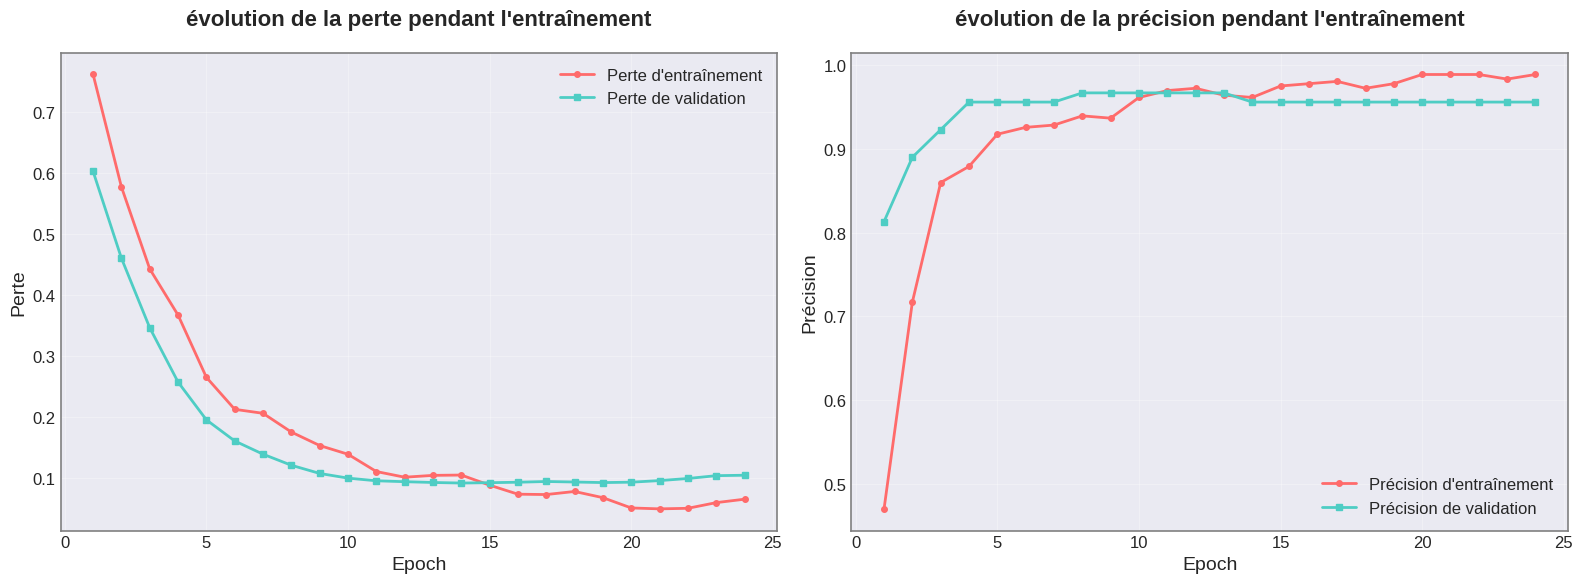

In [16]:
# Création d'une figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Palette de couleurs
train_color = '#FF6B6B'
val_color = '#4ECDC4'

# Graphique de la perte
epochs = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs, history.history['loss'], label='Perte d\'entraînement',
         color=train_color, linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, history.history['val_loss'], label='Perte de validation',
         color=val_color, linewidth=2, marker='s', markersize=4)

ax1.set_title('évolution de la perte pendant l\'entraînement', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=14)
ax1.set_ylabel('Perte', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Graphique de la précision
ax2.plot(epochs, history.history['accuracy'], label='Précision d\'entraînement',
         color=train_color, linewidth=2, marker='o', markersize=4)
ax2.plot(epochs, history.history['val_accuracy'], label='Précision de validation',
         color=val_color, linewidth=2, marker='s', markersize=4)

ax2.set_title('évolution de la précision pendant l\'entraînement', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=14)
ax2.set_ylabel('Précision', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

# Ajout de bordures
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

##  8. Évaluation du modèle

_Évaluation des performances du modèle sur l'ensemble de test._



In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Perte sur l'ensemble de test: {test_loss:.4f}")
print(f"Précision sur l'ensemble de test: {test_accuracy:.4f}")

Perte sur l'ensemble de test: 0.0833
Précision sur l'ensemble de test: 0.9649


### Tableau de bord de performance

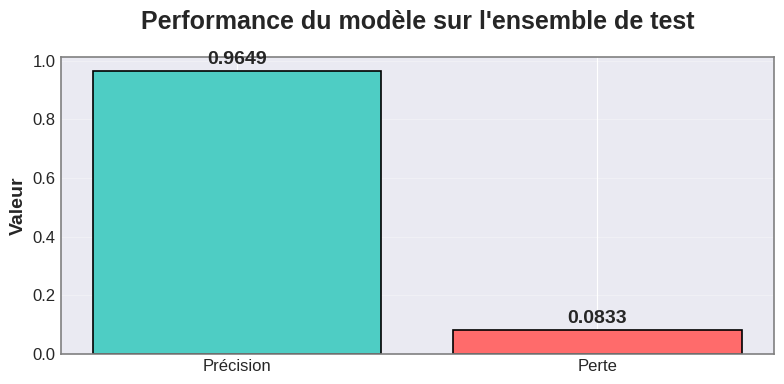

In [18]:
# Création d'un tableau de bord stylé
fig, ax = plt.subplots(figsize=(8, 4))

# Données
metrics = ['Précision', 'Perte']
values = [test_accuracy, test_loss]
colors = ['#4ECDC4', '#FF6B6B']

# Création du graphique à barres
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)

# Ajout des valeurs au-dessus des barres
for i, (bar, value) in enumerate(zip(bars, values)):
    height = bar.get_height()
    if i == 0:  # Précision
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=14)
    else:  # Perte
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

ax.set_title('Performance du modèle sur l\'ensemble de test', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Valeur', fontsize=14, fontweight='bold')

# Ajout d'une grille
ax.grid(True, alpha=0.3, axis='y')

# Style des axes
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

###  Prédiction sur l'ensemble de test

In [19]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Affichage des premières prédictions
results_df = pd.DataFrame({'Valeurs réelles': y_test, 'Prédictions': y_pred, 'Probabilités': y_pred_proba.flatten()})
print("Comparaison des valeurs réelles et prédites:")
print(results_df.head(10))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Comparaison des valeurs réelles et prédites:
     Valeurs réelles  Prédictions  Probabilités
256                0            0  2.575739e-06
428                1            1  9.999914e-01
501                0            0  1.537052e-02
363                1            0  3.262131e-01
564                0            0  1.129700e-06
464                1            1  9.968235e-01
358                1            1  9.999557e-01
343                0            0  2.825355e-05
516                0            0  3.897274e-04
567                0            0  1.292347e-08


###  Rapport de classification détaillé

In [20]:
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))


Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



###  Matrice de confusion

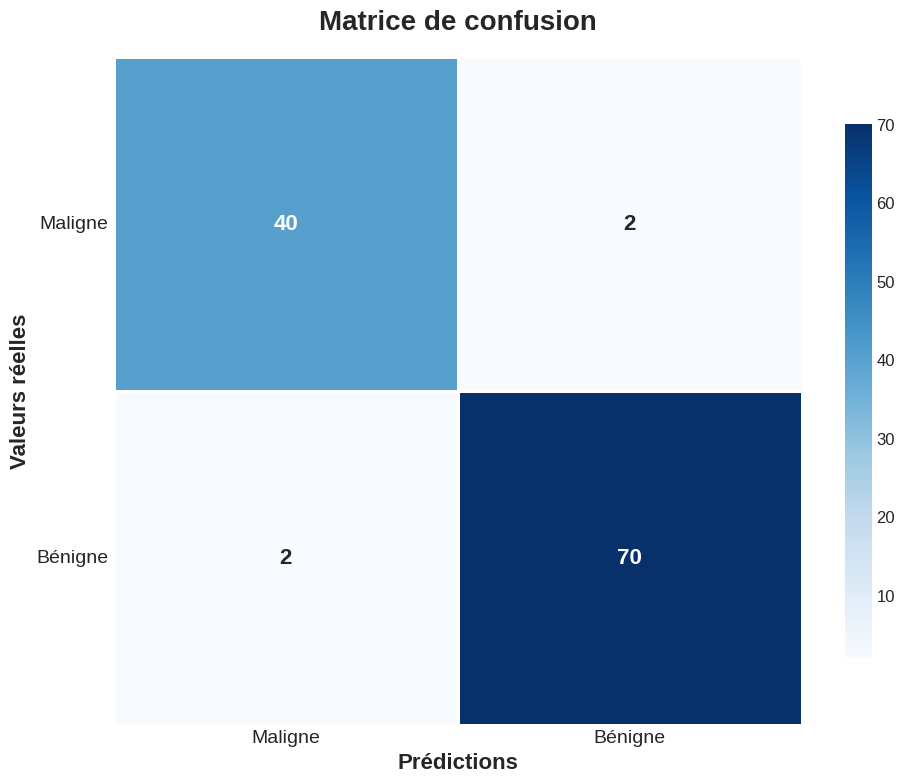

In [21]:
cm = confusion_matrix(y_test, y_pred)

# Création d'une matrice de confusion stylée
plt.figure(figsize=(10, 8))

# Palette de couleurs personnalisée
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 16, 'fontweight': 'bold'})

plt.title('Matrice de confusion', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Prédictions', fontsize=16, fontweight='bold')
plt.ylabel('Valeurs réelles', fontsize=16, fontweight='bold')

# Ajout de labels personnalisés
plt.xticks([0.5, 1.5], ['Maligne', 'Bénigne'], fontsize=14)
plt.yticks([0.5, 1.5], ['Maligne', 'Bénigne'], fontsize=14, rotation=0)

# Ajout d'une bordure
for spine in plt.gca().spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

**texte en gras**###  Courbe ROC et AUC stylée

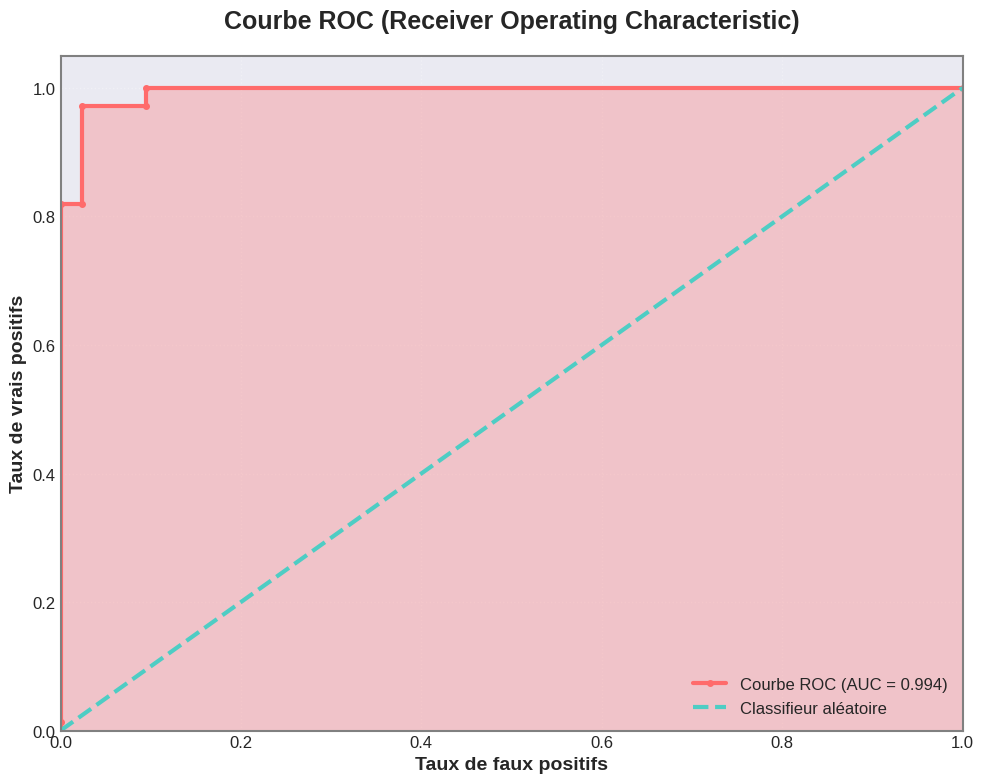


🎯 Aire sous la courbe ROC (AUC): 0.9937


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Création d'une courbe ROC stylée
plt.figure(figsize=(10, 8))

# Tracé de la courbe ROC
plt.plot(fpr, tpr, color='#FF6B6B', lw=3, label=f'Courbe ROC (AUC = {roc_auc:.3f})', marker='o', markersize=4)
plt.plot([0, 1], [0, 1], color='#4ECDC4', lw=3, linestyle='--', label='Classifieur aléatoire')

# Remplissage sous la courbe
plt.fill_between(fpr, tpr, alpha=0.3, color='#FF6B6B')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs', fontsize=14, fontweight='bold')
plt.ylabel('Taux de vrais positifs', fontsize=14, fontweight='bold')
plt.title('Courbe ROC (Receiver Operating Characteristic)', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)

# Grille stylée
plt.grid(True, alpha=0.3, linestyle=':', linewidth=1)

# Ajout d'une bordure
for spine in plt.gca().spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

print(f"\n🎯 Aire sous la courbe ROC (AUC): {roc_auc:.4f}")

##  9. Identification et résolution du sur-apprentissage

> _Analyse des signes de sur-apprentissage et techniques pour l'atténuer._

###  Analyse de l'écart entre les performances d'entraînement et de validation

In [23]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"Précision d'entraînement finale: {train_acc:.4f}")
print(f"Précision de validation finale: {val_acc:.4f}")
print(f"Écart de précision: {abs(train_acc - val_acc):.4f}")

print(f"\nPerte d'entraînement finale: {train_loss:.4f}")
print(f"Perte de validation finale: {val_loss:.4f}")
print(f"Écart de perte: {abs(train_loss - val_loss):.4f}")

Précision d'entraînement finale: 0.9890
Précision de validation finale: 0.9560
Écart de précision: 0.0330

Perte d'entraînement finale: 0.0659
Perte de validation finale: 0.1052
Écart de perte: 0.0393


###  Détection du sur-apprentissage

In [24]:
# Si l'écart est significatif, il peut y avoir du sur-apprentissage
if abs(train_acc - val_acc) > 0.05:
    print("\n⚠️  Signes possibles de sur-apprentissage détectés")
    print(" Recommandations:")
    print("   - Augmenter le taux de dropout")
    print("   - Ajouter plus de régularisation")
    print("   - Réduire la complexité du modèle")
    print("   - Collecter plus de données")
else:
    print("\n✅ Pas de sur-apprentissage significatif détecté")
    print("🎉 Bonne généralisation du modèle!")


✅ Pas de sur-apprentissage significatif détecté
🎉 Bonne généralisation du modèle!


##  10. Amélioration du modèle

> _Création d'une version améliorée du modèle avec des techniques supplémentaires de régularisation._

###  Modèle amélioré avec plus de régularisation

In [25]:
improved_model = keras.Sequential([
    # Couche d'entrée avec BatchNormalization
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Première couche cachée
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Deuxième couche cachée
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Couche de sortie
    layers.Dense(1, activation='sigmoid')
])

# Compilation du modèle amélioré
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**texte en gras* Structure du modèle amélioré

In [26]:
print("Structure du modèle amélioré:")
improved_model.summary()

Structure du modèle amélioré:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 224 (896.00 B)

*texte en italique*###  Entraînement du modèle amélioré

In [27]:
improved_history = improved_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4781 - loss: 0.8846 - val_accuracy: 0.6703 - val_loss: 0.6271 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6272 - loss: 0.7250 - val_accuracy: 0.8571 - val_loss: 0.5396 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6684 - loss: 0.6029 - val_accuracy: 0.9011 - val_loss: 0.4832 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7173 - loss: 0.5634 - val_accuracy: 0.9011 - val_loss: 0.4367 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7770 - loss: 0.5176 - val_accuracy: 0.8901 - val_loss: 0.3937 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8500 - loss: 0.3714 - val_accuracy: 0.9231 - val_loss: 0.3575 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8030 - loss: 0.4567 - val

### 📊 Évaluation du modèle amélioré

In [28]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f"\nPerformances du modèle amélioré sur l'ensemble de test:")
print(f"Perte: {improved_test_loss:.4f}")
print(f"Précision: {improved_test_accuracy:.4f}")

print(f"\nComparaison avec le modèle initial:")
print(f"Amélioration de la précision: {improved_test_accuracy - test_accuracy:.4f}")


Performances du modèle amélioré sur l'ensemble de test:
Perte: 0.0966
Précision: 0.9561

Comparaison avec le modèle initial:
Amélioration de la précision: -0.0088


### 📈 Comparaison visuelle des performances

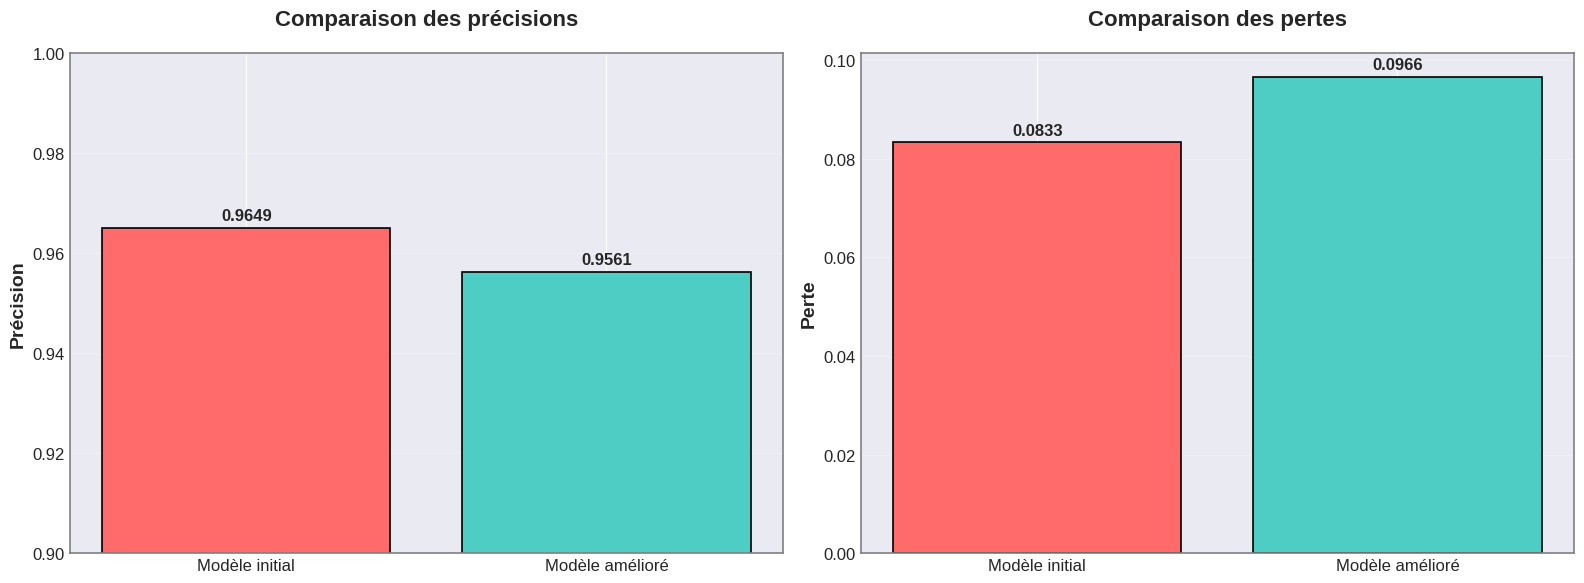

In [29]:
# Données pour la comparaison
models = ['Modèle initial', 'Modèle amélioré']
accuracies = [test_accuracy, improved_test_accuracy]
losses = [test_loss, improved_test_loss]

# Création d'une figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Palette de couleurs
colors = ['#FF6B6B', '#4ECDC4']

# Graphique de comparaison des précisions
bars1 = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_title('Comparaison des précisions', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Précision', fontsize=14, fontweight='bold')
ax1.set_ylim([0.9, 1.0])

# Ajout des valeurs au-dessus des barres
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Graphique de comparaison des pertes
bars2 = ax2.bar(models, losses, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_title('Comparaison des pertes', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Perte', fontsize=14, fontweight='bold')

# Ajout des valeurs au-dessus des barres
for bar, loss in zip(bars2, losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{loss:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Ajout de grilles
for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3, axis='y')
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

## 📈 11. Visualisation des résultats du modèle amélioré

### 📉 Courbes d'apprentissage du modèle amélioré

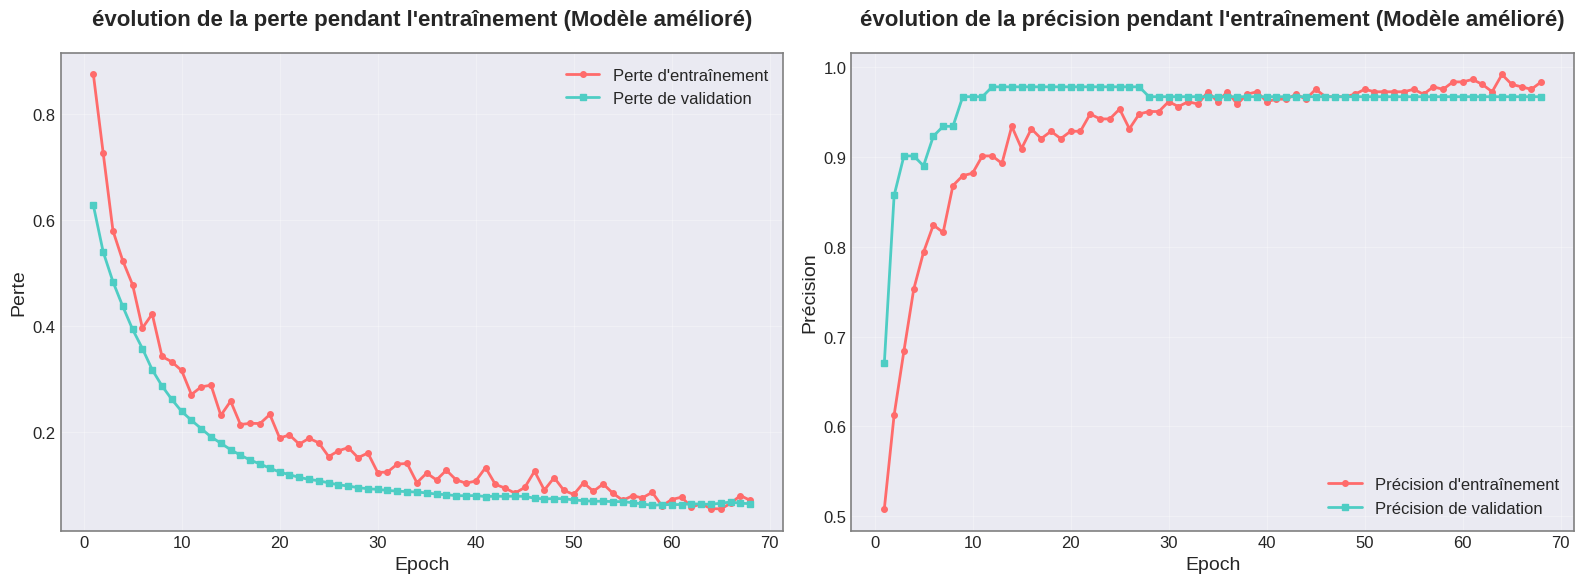

In [30]:
# Création d'une figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Palette de couleurs
train_color = '#FF6B6B'
val_color = '#4ECDC4'

# Graphique de la perte
epochs = range(1, len(improved_history.history['loss']) + 1)

ax1.plot(epochs, improved_history.history['loss'], label='Perte d\'entraînement',
         color=train_color, linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, improved_history.history['val_loss'], label='Perte de validation',
         color=val_color, linewidth=2, marker='s', markersize=4)

ax1.set_title('évolution de la perte pendant l\'entraînement (Modèle amélioré)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=14)
ax1.set_ylabel('Perte', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Graphique de la précision
ax2.plot(epochs, improved_history.history['accuracy'], label='Précision d\'entraînement',
         color=train_color, linewidth=2, marker='o', markersize=4)
ax2.plot(epochs, improved_history.history['val_accuracy'], label='Précision de validation',
         color=val_color, linewidth=2, marker='s', markersize=4)

ax2.set_title('évolution de la précision pendant l\'entraînement (Modèle amélioré)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=14)
ax2.set_ylabel('Précision', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

# Ajout de bordures
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()



###  final :

✅ **Chargement et exploration des données** du cancer du sein
✅ **Prétraitement des données** avec normalisation
✅ **Division des données** en ensembles d'entraînement, de validation et de test
✅ **Construction d'un modèle de réseau de neurones** avec plusieurs couches
✅ **Entraînement du modèle** avec suivi des courbes d'apprentissage
✅ **Évaluation des performances** avec plusieurs métriques (précision, rappel, F1-score, AUC)
✅ **Visualisation des résultats** (matrice de confusion, courbe ROC)
✅ **Identification et atténuation du sur-apprentissage**
✅ **Amélioration du modèle** avec des techniques avancées de régularisation

###  Points clés à retenir :

 Les réseaux de neurones sont des modèles très puissants capables d'apprendre des représentations complexes dans les données
 La **normalisation des données** est cruciale pour la convergence
 La **validation croisée** et l'ensemble de validation sont essentiels pour surveiller les performances
 Des techniques comme le **dropout** et la **normalisation par lots** aident à prévenir le sur-apprentissage
 L'**arrêt anticipé** et la **réduction du taux d'apprentissage** optimisent l'entraînement

